In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14516\3062298247.py:1: DtypeWarning: Columns (0: abbreviated_product_name, 1: packaging_text, 2: no_nutrition_data) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"..\data\en.openfoodfacts.org.products.csv.gz", sep="\t", encoding='utf-8', nrows=10000)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
scores_connus = ['a', 'b', 'c', 'd', 'e']
df_connu = df[df['nutriscore_grade'].isin(scores_connus)].copy()

# DataFrame avec le reste (unknown, not-applicable, ou NaN éventuels)
df_inconnu = df[~df['nutriscore_grade'].isin(scores_connus)].copy()

# Vérification rapide
print("Connu :", df_connu.shape)
print("Inconnu :", df_inconnu.shape)
print(df_connu['nutriscore_grade'].value_counts())
print(df_inconnu['nutriscore_grade'].value_counts(dropna=False))

Connu : (965, 211)
Inconnu : (9035, 211)
nutriscore_grade
e    306
d    209
c    190
a    171
b     89
Name: count, dtype: int64
nutriscore_grade
unknown           8455
NaN                313
not-applicable     267
Name: count, dtype: int64


In [42]:
mes_features = ['saturated-fat_100g', 'sugars_100g', 'salt_100g',
            'fiber_100g', 'proteins_100g', 'fruits-vegetables-legumes_100g',
            'fat_100g', 'carbohydrates_100g', 'nova_group', 'additives_n', 
            'energy_100g', 'added-sugars_100g', 'trans-fat_100g']

In [43]:
#Nettoyage minimal des données
percent_missing = df_connu[features].isnull().sum() * 100 / len(df_connu)
percent_missing.sort_values(ascending=False,inplace=True)

In [44]:
print(percent_missing)

fruits-vegetables-legumes_100g    73.160622
fiber_100g                        60.103627
nova_group                        46.424870
additives_n                       41.761658
carbohydrates_100g                40.310881
saturated-fat_100g                40.310881
sugars_100g                       40.310881
energy-kcal_100g                  40.207254
salt_100g                         40.207254
proteins_100g                     40.207254
fat_100g                          40.207254
dtype: float64


In [45]:
## On retire les features avec + de 60% de valeurs manquantes
threshold = 80
columns_to_drop = percent_missing[percent_missing.values > threshold].index
print(columns_to_drop)
# features_restantes = [f for f in features if f not in columns_to_drop]
features_restantes = [f for f in features if f != 'fruits-vegetables-legumes_100g'] # plus problematique"

Index([], dtype='str')


In [46]:
##il y a des lignes avec des NaN dans chaque features, il faut les supprimer !
df_restr = df_connu[features_restantes + ['nutriscore_grade']].copy() 
n_features = len(features_restantes)
df_restr= df_restr[df_restr[features_restantes].isna().sum(axis=1) != n_features]

In [47]:
df_restr.shape

(885, 11)

In [48]:
# 4. SPLIT MAINTENANT, avant imputation et avant traitement des outliers
X =df_restr[features_restantes]
y = df_restr['nutriscore_grade']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
def apply_impossible_nan(X, y=None):
    X = X.copy()   # on travaille sur une copie pour ne pas modifier l'original

    # on regarde chaque colonne
    for col in X.columns:
        # on choisit les bonnes bornes selon la colonne
        if not pd.api.types.is_numeric_dtype(X[col]):
            continue

        if col in BORNES_SPECIFIQUES:
            bas, haut = BORNES_SPECIFIQUES[col]
        elif col == COLONNE_ENERGIE:
            bas, haut = BORNE_ENERGIE
        elif col.endswith("_100g"):
            bas, haut = BORNE_NUTRIMENT
        else:
            # colonne numérique sans borne physique connue -> on ne touche pas
            continue

        # les valeurs impossibles (hors bornes) deviennent NaN
        # notna() évite de toucher aux NaN déjà présents
        impossible = X[col].notna() & ~X[col].between(bas, haut)
        X.loc[impossible, col] = np.nan

    # si pas de y : on renvoie juste X
    if y is None:
        return X

    # sinon on renvoie X et y (y n'a pas changé, aucune ligne supprimée)
    return X, y

In [50]:
from sklearn.impute import SimpleImputer
# 5. Imputation : fit UNIQUEMENT sur train, puis transform sur train ET test
imputer = SimpleImputer(strategy='mean')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train), columns=features_restantes, index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test), columns=features_restantes, index=X_test.index
)

In [51]:
from version3 import (
    train_logistic_multinomial,
    train_logistic_ovr,
    evaluate_model,
    grid_search_multinomial,
    grid_search_ovr,
)
logistic_regression_multinomial = train_logistic_multinomial(
    X_train_imputed,
    y_train
)

logistic_regression_ovr = train_logistic_ovr(
    X_train_imputed,
    y_train
)

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [52]:
accuracy_multinomial = evaluate_model(
    logistic_regression_multinomial,
    X_test_imputed,
    y_test
)

accuracy_ovr = evaluate_model(
    logistic_regression_ovr,
    X_test_imputed,
    y_test
)


In [53]:
print (accuracy_multinomial)
print (accuracy_ovr)

0.5423728813559322
0.5423728813559322


In [54]:
grid_multinomial = grid_search_multinomial(
    X_train_imputed,
    y_train
)

print("Meilleurs paramètres :", grid_multinomial.best_params_)
print("Meilleure accuracy CV :", grid_multinomial.best_score_)

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

Meilleurs paramètres : {'C': 100, 'max_iter': 2000}
Meilleure accuracy CV : 0.5663669963040656


c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
grid_ovr = grid_search_ovr(
    X_train_imputed,
    y_train
)

print("Meilleurs paramètres :", grid_ovr.best_params_)
print("Meilleure accuracy CV :", grid_ovr.best_score_)

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

Meilleurs paramètres : {'estimator__C': 100, 'estimator__max_iter': 500}
Meilleure accuracy CV : 0.5452002796923384


In [56]:
best_multinomial = grid_multinomial.best_estimator_
best_ovr = grid_ovr.best_estimator_

accuracy_multinomial = best_multinomial.score(
    X_test_imputed,
    y_test
)

accuracy_ovr = best_ovr.score(
    X_test_imputed,
    y_test
)

print("Test - Multinomial :", accuracy_multinomial)
print("Test - OvR :", accuracy_ovr)

Test - Multinomial : 0.5706214689265536
Test - OvR : 0.5423728813559322


On a des scores d'accuracy très proches entre Train-Test pour multinomial et Ovr respectivement avec les meilleurs hyperparametres mais modele reste un peu en sous apprentissage? Le mod multinomial a l'air d'etre plus performant

In [57]:
features_visu = [
    'salt_100g',
    'saturated-fat_100g'
]

X_train_visu = X_train_imputed[features_visu]
X_test_visu = X_test_imputed[features_visu]

In [58]:
model_multinomial_visu = train_logistic_multinomial(
    X_train_visu,
    y_train
)

model_ovr_visu = train_logistic_ovr(
    X_train_visu,
    y_train
)

In [59]:
accuracy_multinomial_visu = model_multinomial_visu.score(
    X_test_visu,
    y_test
)

accuracy_ovr_visu = model_ovr_visu.score(
    X_test_visu,
    y_test
)

# Decision Boundary

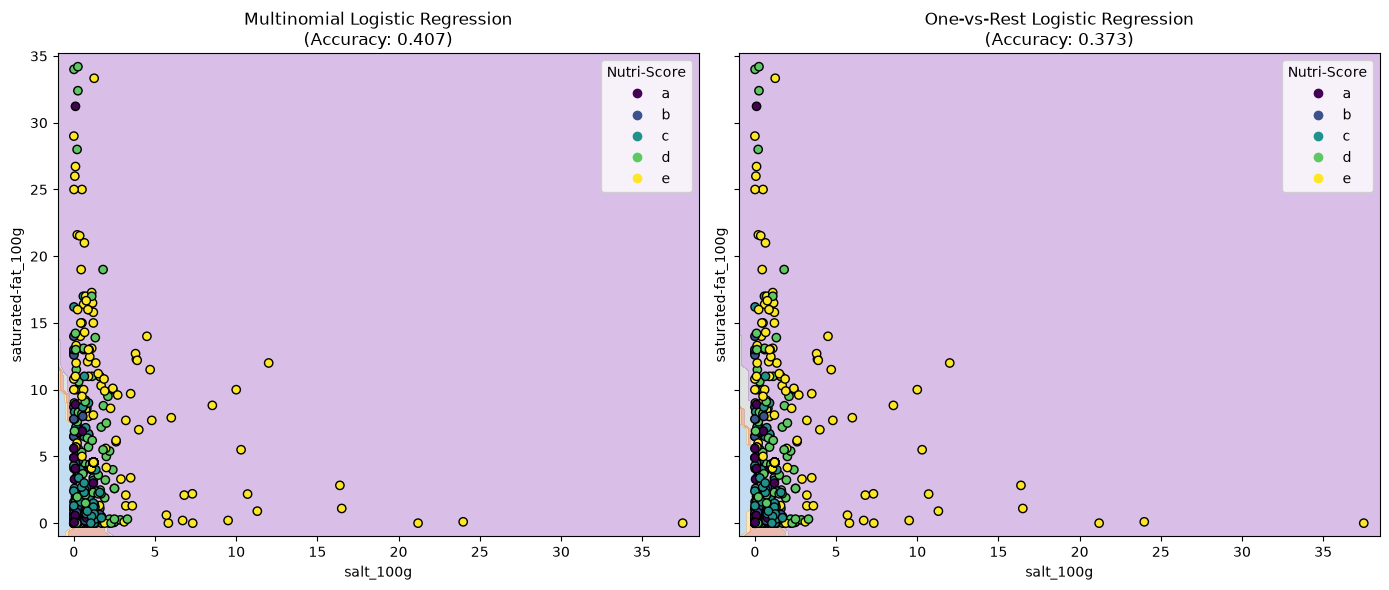

In [89]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharex=True,
    sharey=True
)

# On convertit une seule fois, pour être sûr d'avoir le même mapping partout
y_train_cat = y_train.astype("category")
y_codes = y_train_cat.cat.codes
categories = y_train_cat.cat.categories  # ex : Index(['a', 'b', 'c', 'd', 'e'])

for model, title, ax in [
    (
        model_multinomial_visu,
        f"Multinomial Logistic Regression\n"
        f"(Accuracy: {accuracy_multinomial_visu:.3f})",
        ax1,
    ),
    (
        model_ovr_visu,
        f"One-vs-Rest Logistic Regression\n"
        f"(Accuracy: {accuracy_ovr_visu:.3f})",
        ax2,
    ),
]:

    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train_visu,
        ax=ax,
        response_method="predict",
        alpha=0.3
    )

    scatter = ax.scatter(
        X_train_visu.iloc[:, 0],
        X_train_visu.iloc[:, 1],
        c=y_codes,
        edgecolor="k"
    )

    ax.set_xlabel(features_visu[0])
    ax.set_ylabel(features_visu[1])
    ax.set_title(title)

    # Légende : associe chaque couleur au vrai label de catégorie
    handles, _ = scatter.legend_elements()
    ax.legend(handles, categories, title="Nutri-Score")

plt.tight_layout()
plt.show()

In [61]:
from version3 import calculate_log_loss

In [62]:
loss_multinomial = calculate_log_loss(
    logistic_regression_multinomial,
    X_test_imputed,
    y_test
)

loss_ovr = calculate_log_loss(
    logistic_regression_ovr,
    X_test_imputed,
    y_test
)

print("Multinomial")
print("Accuracy :", accuracy_multinomial)
print("Log-loss :", loss_multinomial)

print("\nOne-vs-Rest")
print("Accuracy :", accuracy_ovr)
print("Log-loss :", loss_ovr)

Multinomial
Accuracy : 0.5706214689265536
Log-loss : 1.1302667425081148

One-vs-Rest
Accuracy : 0.5423728813559322
Log-loss : 1.185433757924348


La log loss dit à quel point le modele predit correctement. Pour tes 5 classes, un modèle qui devine au hasard obtient environ 1.61. La on a des mod qui ont une log loss en dessous donc le modele garde des informations utiles

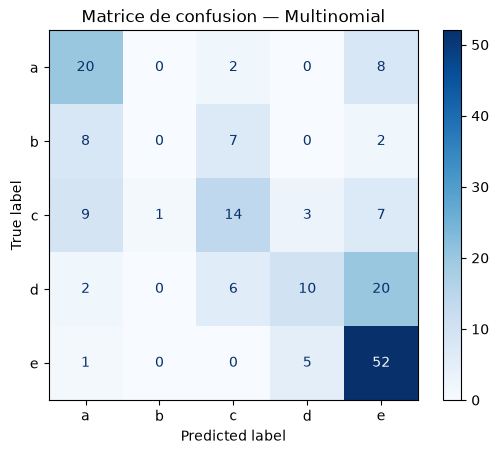

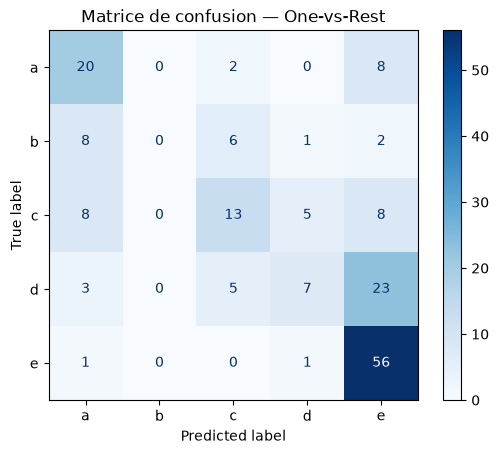

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Modèle Multinomial ---
y_pred_multinomial = logistic_regression_multinomial.predict(X_test_imputed)

cm_multinomial = confusion_matrix(y_test, y_pred_multinomial)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multinomial,
    display_labels=logistic_regression_multinomial.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de confusion — Multinomial")
plt.show()

# --- Modèle One-vs-Rest ---
y_pred_ovr = logistic_regression_ovr.predict(X_test_imputed)

cm_ovr = confusion_matrix(y_test, y_pred_ovr)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ovr,
    display_labels=logistic_regression_ovr.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title("Matrice de confusion — One-vs-Rest")
plt.show()

# (a, b, c, d, e) sont déséquilibrées --> normalisation : Chq colonne est divisée par le total de cette colonne (le nombre de fois où le modèle a prédit cette classe).

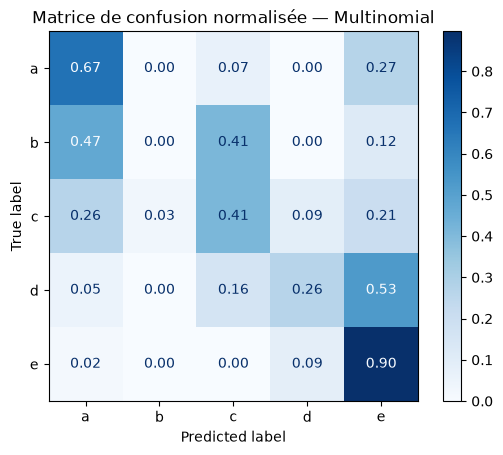

In [93]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_multinomial,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)
plt.title("Matrice de confusion normalisée — Multinomial")
plt.show()

In [65]:
import importlib
import version3

importlib.reload(version3)

<module 'version3' from 'c:\\DESU\\DESU_ROCHET\\test\\version3.py'>

In [66]:
from version3 import plot_loss_train_test


c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please a

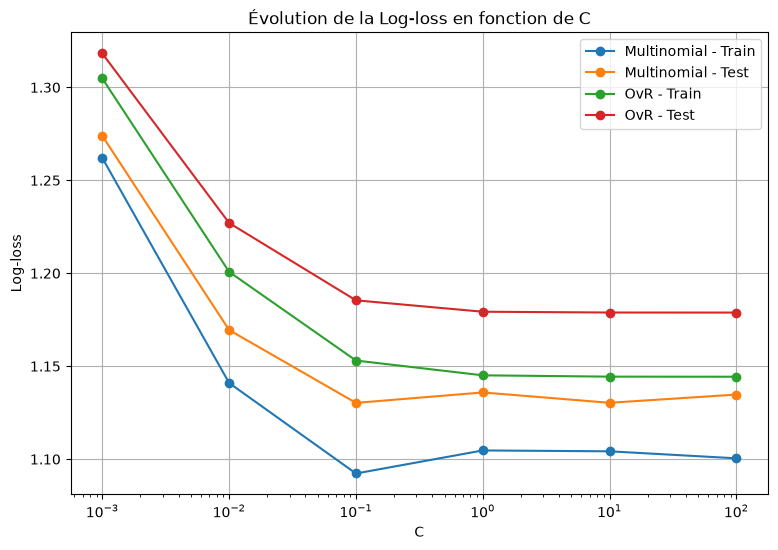

In [67]:
plot_loss_train_test(
    X_train_imputed,
    y_train,
    X_test_imputed,
    y_test
)

In [68]:
from version3 import train_logistic_multinomial, evaluate_model

# Entraînement du modèle multinomial avec C=0.1
model_multinomial_C01 = train_logistic_multinomial(
    X_train_imputed,
    y_train,
    C=0.1
)

# Évaluation
accuracy_C01 = evaluate_model(
    model_multinomial_C01,
    X_test_imputed,
    y_test
)

print("Régression logistique multinomiale (C=0.1)")
print(f"Accuracy test : {accuracy_C01:.3f}")
print("\nCoefficients par classe :")
for classe, coefs in zip(model_multinomial_C01.classes_, model_multinomial_C01.coef_):
    print(f"\nClasse '{classe}' :")
    for nom_var, coef in zip(X_train_imputed.columns, coefs):
        print(f"  {nom_var}: {coef:.4f}")

Régression logistique multinomiale (C=0.1)
Accuracy test : 0.542

Coefficients par classe :

Classe 'a' :
  energy-kcal_100g: -0.0030
  saturated-fat_100g: -0.2819
  sugars_100g: -0.0476
  salt_100g: -0.7439
  fiber_100g: 0.0848
  proteins_100g: 0.0705
  fat_100g: 0.0462
  carbohydrates_100g: 0.0185
  nova_group: -0.4040
  additives_n: -0.2928

Classe 'b' :
  energy-kcal_100g: -0.0005
  saturated-fat_100g: -0.1336
  sugars_100g: -0.1006
  salt_100g: -0.9208
  fiber_100g: 0.0360
  proteins_100g: 0.0119
  fat_100g: 0.0290
  carbohydrates_100g: -0.0030
  nova_group: 0.1555
  additives_n: -0.0559

Classe 'c' :
  energy-kcal_100g: 0.0063
  saturated-fat_100g: -0.1642
  sugars_100g: -0.0141
  salt_100g: -0.2985
  fiber_100g: 0.0191
  proteins_100g: -0.0256
  fat_100g: -0.0408
  carbohydrates_100g: -0.0206
  nova_group: 0.2681
  additives_n: 0.0192

Classe 'd' :
  energy-kcal_100g: 0.0050
  saturated-fat_100g: 0.2396
  sugars_100g: 0.0531
  salt_100g: 0.6669
  fiber_100g: -0.0196
  proteins_1

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [69]:
from version3 import grid_search_multinomial_v2

grid_multinomial_v2 = grid_search_multinomial_v2(X_train_imputed, y_train)

print("Meilleurs paramètres :", grid_multinomial_v2.best_params_)
print("Meilleure accuracy CV :", grid_multinomial_v2.best_score_)

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio

Meilleurs paramètres : {'C': 0.1, 'class_weight': None, 'max_iter': 2000, 'penalty': 'l1', 'solver': 'saga'}
Meilleure accuracy CV : 0.43504145440015984


c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [70]:
from sklearn.linear_model import LogisticRegression
from version3 import evaluate_model

model_multinomial_custom = LogisticRegression(
    C=0.1,
    class_weight="balanced",
    max_iter=2000,
    penalty='l1',
    solver='saga'
)
model_multinomial_custom.fit(X_train_imputed, y_train)

accuracy_custom = evaluate_model(model_multinomial_custom, X_test_imputed, y_test)
print(f"Accuracy test : {accuracy_custom:.3f}")

c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Accuracy test : 0.395


c:\DESU\DESU_ROCHET\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


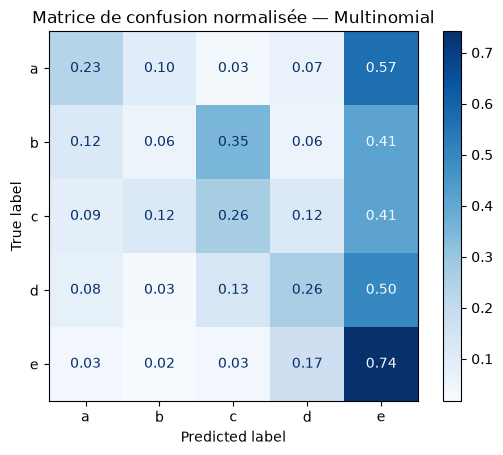

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Modèle Multinomial ---
y_pred_multinomial = model_multinomial_custom.predict(X_test_imputed)

cm_multinomial = confusion_matrix(y_test, y_pred_multinomial)


disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_multinomial,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)
plt.title("Matrice de confusion normalisée — Multinomial")
plt.show()

In [72]:
import importlib
import version3
importlib.reload(version3)

<module 'version3' from 'c:\\DESU\\DESU_ROCHET\\test\\version3.py'>

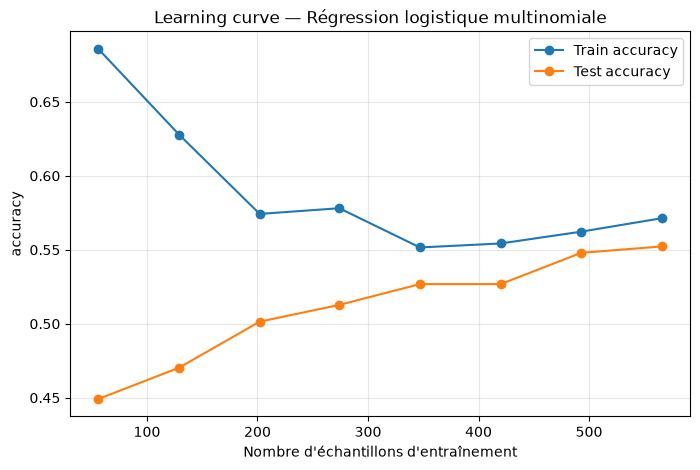

In [73]:
from version3 import plot_learning_curve_sklearn
from sklearn.linear_model import LogisticRegression

model_C01 = LogisticRegression(C=0.1, max_iter=1000)

train_sizes, train_scores, test_scores = plot_learning_curve_sklearn(
    model_C01,
    X_train_imputed,
    y_train,
    cv=5,
    scoring="accuracy"
)

# Correlation matrice pour selection de features

In [74]:
from version2 import (
    plot_correlation_matrix,
    compute_vif,)


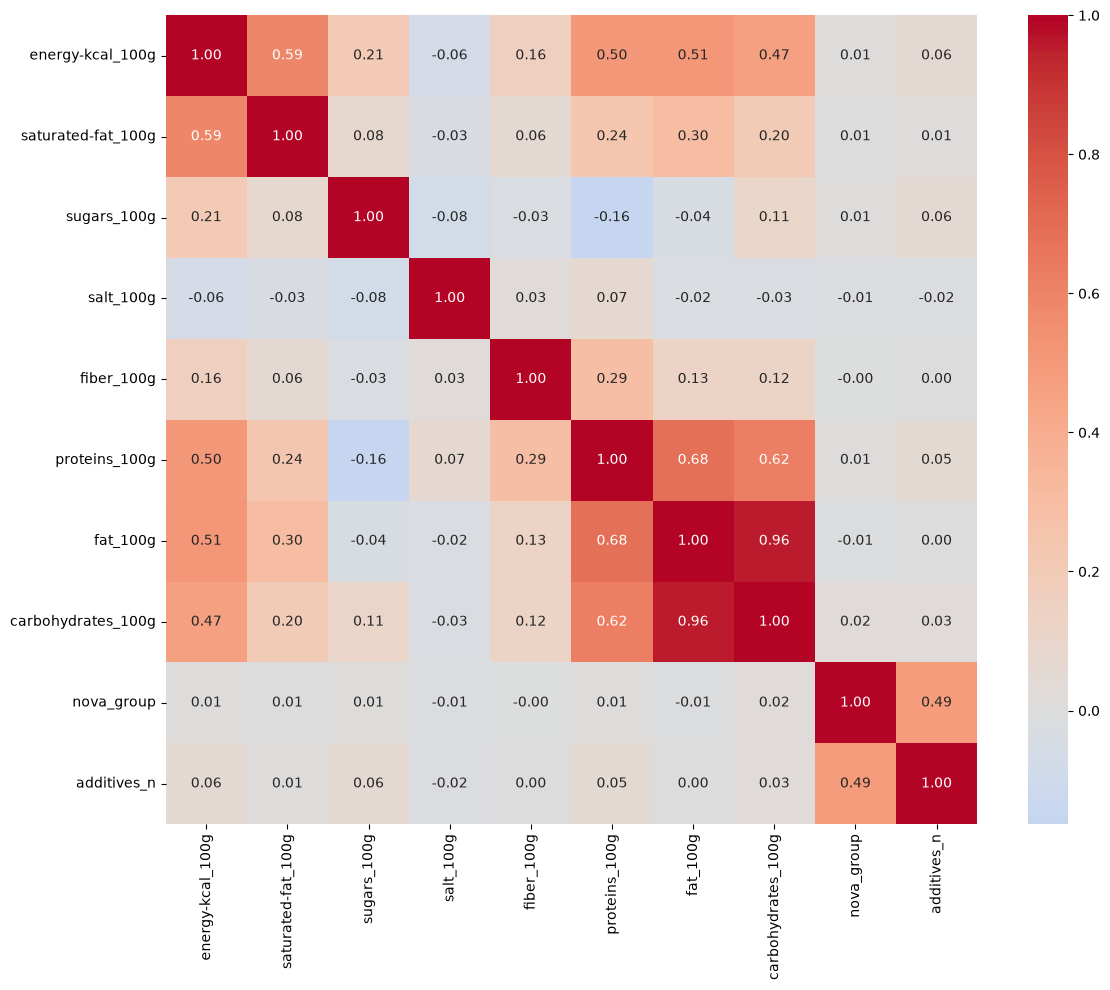

In [75]:
corr = plot_correlation_matrix(X_train_imputed)


In [76]:
vif_data, vif_ok = compute_vif(X_train_imputed)

             variable        VIF
0    energy-kcal_100g   2.263417
1  saturated-fat_100g   1.822458
2         sugars_100g   1.667506
3           salt_100g   1.026600
4          fiber_100g   1.112701
5       proteins_100g   2.383096
6            fat_100g  23.396630
7  carbohydrates_100g  20.736232
8          nova_group   1.328045
9         additives_n   1.325949

Variables gardées (VIF < 5.0) : ['energy-kcal_100g', 'saturated-fat_100g', 'sugars_100g', 'salt_100g', 'fiber_100g', 'proteins_100g', 'nova_group', 'additives_n']


# On applique le modele sur df_inconnu

In [77]:
# 1. Sélectionner les mêmes features que pour l'entraînement
X_inconnu = df_inconnu[features_restantes].copy()

# 2. Appliquer l'IMPUTER déjà entraîné (fit sur X_train, jamais refit ici)
X_inconnu_imputed = pd.DataFrame(
    imputer.transform(X_inconnu),
    columns=features_restantes,
    index=X_inconnu.index
)

# 3. Prédire avec le modèle entraîné
y_pred_inconnu = logistic_regression_multinomial.predict(X_inconnu_imputed)
y_proba_inconnu = logistic_regression_multinomial.predict_proba(X_inconnu_imputed)

# 4. Ajouter les prédictions au dataframe original
df_inconnu['nutriscore_predit'] = y_pred_inconnu

In [78]:
df_inconnu['nutriscore_predit'].value_counts(normalize=True)

nutriscore_predit
e    0.775761
c    0.092861
a    0.072274
d    0.051245
b    0.007858
Name: proportion, dtype: float64

In [79]:
X_inconnu.isna().sum()

energy-kcal_100g      6188
saturated-fat_100g    6492
sugars_100g           6439
salt_100g             7263
fiber_100g            7407
proteins_100g         6319
fat_100g              6345
carbohydrates_100g    6267
nova_group            8467
additives_n           8184
dtype: int64